# Weights Analysis Between Models

In [1]:
%cd ../

/Users/Efecan/Desktop/Thesus/vision_transformer


In [12]:
import torch
from models.vision_transformer import VisionTransformer  # Import your ViT model class
from models.recurrent_vit import RecurrentVisionTransformer


model_standard = VisionTransformer(img_size=32,
        patch_size=4,
        in_channels=3,
        num_classes=10,
        embed_dim=256,
        depth=12,
        num_heads=8,
        hidden_size=1024,  
        dropout=0.1)

model_swapped = VisionTransformer(img_size=32,
        patch_size=4,
        in_channels=3,
        num_classes=10,
        embed_dim=256,
        depth=12,
        num_heads=8,
        hidden_size=1024,  
        dropout=0.1)  

model_recurrent = RecurrentVisionTransformer(img_size=32,
        patch_size=4,
        in_channels=3,
        num_classes=10,
        embed_dim=256,
        num_steps=12,
        num_heads=8,
        hidden_size=1024,  
        dropout=0.1)  


# Load the saved weights
standard_weights_path = "model_weights/model_standard/model_weights.pth"
swapped_weights_path = "model_weights/model_swapped/model_weights.pth"
recurrent_weights_path = "model_weights/model_recurrent/model_weights.pth"



model_standard.load_state_dict(torch.load(standard_weights_path, map_location=torch.device('cpu'), weights_only = True))  
model_swapped.load_state_dict(torch.load(swapped_weights_path, map_location=torch.device('cpu'),weights_only = True))  
model_recurrent.load_state_dict(torch.load(recurrent_weights_path, map_location=torch.device('cpu'),weights_only = True))  

<All keys matched successfully>

In [3]:
import torch
import numpy as np
from geomloss import SamplesLoss

def sinkhorn_emd(W1, W2, blur=0.05, scaling=0.9):
    """Compute permutation-invariant EMD between weight matrices"""
    # Reshape to [neurons, features]
    X = W1.view(W1.shape[0], -1).detach().cpu().numpy()
    Y = W2.view(W2.shape[0], -1).detach().cpu().numpy()
    
    # Convert to PyTorch tensors
    X_ = torch.from_numpy(X).float()
    Y_ = torch.from_numpy(Y).float()
    
    # Sinkhorn divergence (approximates EMD)
    loss = SamplesLoss("sinkhorn", blur=blur, scaling=scaling)
    return loss(X_, Y_).item()

def cka_similarity(W1, W2):
    """CKA similarity between weight matrices"""
    X = W1.view(W1.shape[0], -1).T  # [features, neurons]
    Y = W2.view(W2.shape[0], -1).T
    
    X = X - X.mean(0, keepdim=True)
    Y = Y - Y.mean(0, keepdim=True)
    
    X = X.double()
    Y = Y.double()
    
    K = X @ X.T
    L = Y @ Y.T
    
    hsic = torch.trace(K @ L)
    norm_K = torch.trace(K @ K).sqrt()
    norm_L = torch.trace(L @ L).sqrt()
    
    return (hsic / (norm_K * norm_L)).item()

def compute_pairwise_distances(model, metric_fn):
    """Compute pairwise distances between all encoder layers"""
    layers = [name for name, param in model.named_parameters() 
              if 'blocks' in name and 'attn.qkv.weight' in name]
    params = {name: param for name, param in model.named_parameters()}
    
    distances = np.zeros((len(layers), len(layers)))
    for i, name_i in enumerate(layers):
        for j, name_j in enumerate(layers):
            W_i = params[name_i]
            W_j = params[name_j]
            distances[i, j] = metric_fn(W_i, W_j)
    return distances

In [5]:
# For swapped model
swapped_distances_emd = compute_pairwise_distances(model_swapped, sinkhorn_emd)
swapped_avg_emd = np.mean(swapped_distances_emd)

# For non-swapped model
original_distances_emd = compute_pairwise_distances(model_standard, sinkhorn_emd)
original_avg_emd = np.mean(original_distances_emd)

print(f"Swapped Model Avg EMD: {swapped_avg_emd:.3f}")
print(f"Original Model Avg EMD: {original_avg_emd:.3f}")

Swapped Model Avg EMD: 0.287
Original Model Avg EMD: 0.289


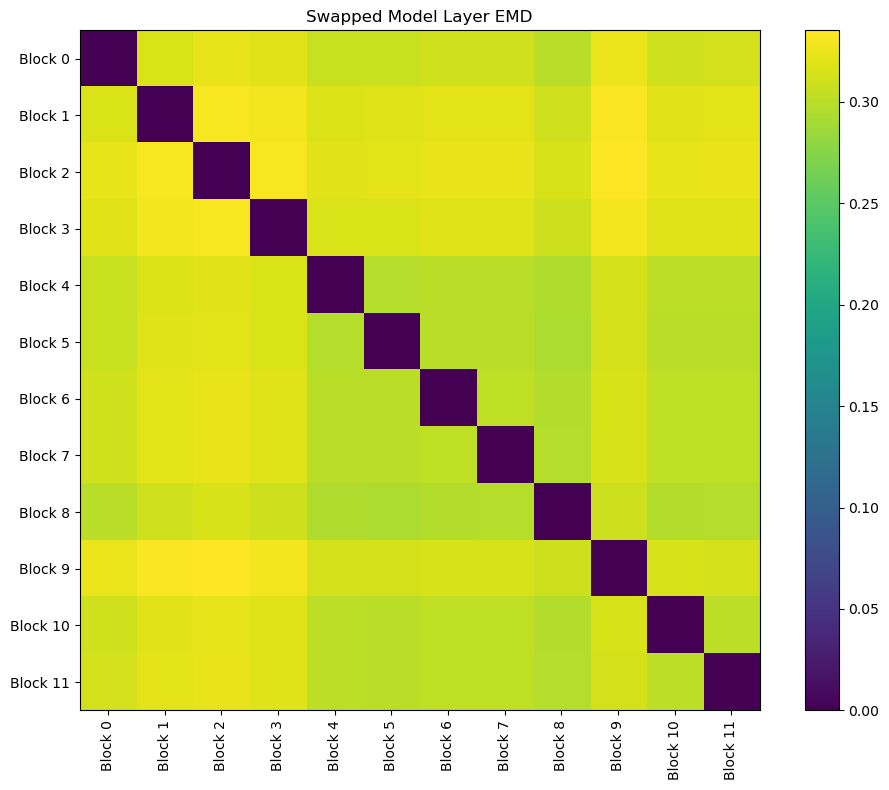

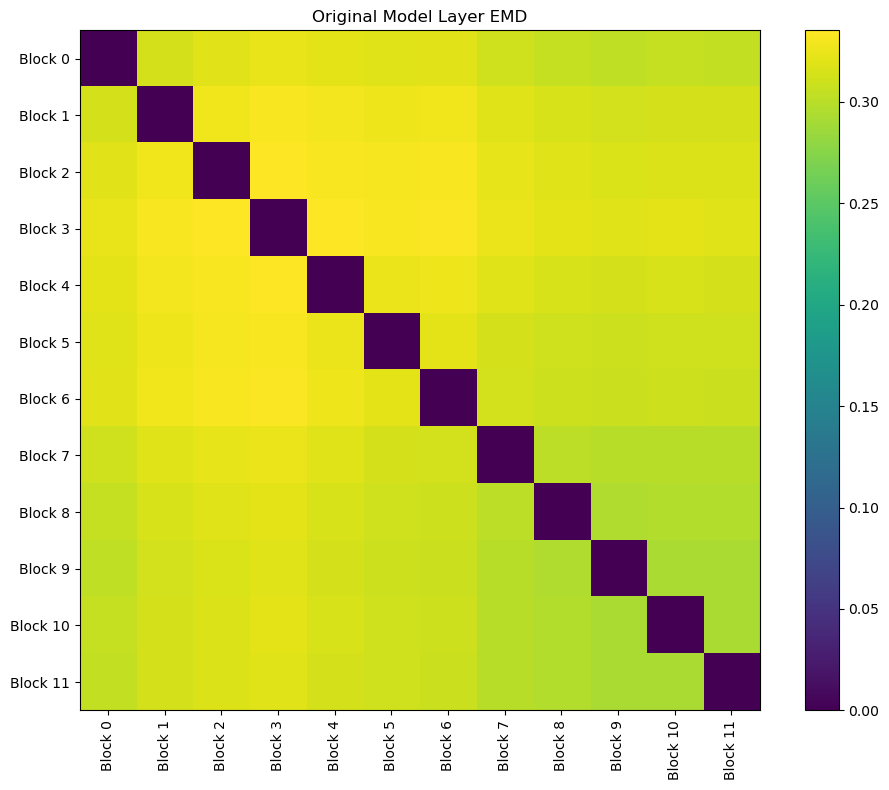

In [6]:
import matplotlib.pyplot as plt

def plot_distance_matrix(matrix, title, layer_names):
    plt.figure(figsize=(10, 8))
    plt.imshow(matrix, cmap='viridis')
    plt.colorbar()
    plt.xticks(np.arange(len(layer_names)), layer_names, rotation=90)
    plt.yticks(np.arange(len(layer_names)), layer_names)
    plt.title(title)
    plt.tight_layout()
    plt.show()

layer_names = [f'Block {i}' for i in range(12)]
plot_distance_matrix(swapped_distances_emd, "Swapped Model Layer EMD", layer_names)
plot_distance_matrix(original_distances_emd, "Original Model Layer EMD", layer_names)

Using device: mps
=== Random Noise Inputs ===
MSE: 0.337293, KL: 0.070074, CosSim: 0.933444


100%|████████████████████████████████████████| 170M/170M [00:09<00:00, 18.7MB/s]


Extracting ./data/cifar-10-python.tar.gz to ./data
=== Augmented CIFAR-10 Inputs ===
MSE: 0.473693, KL: 0.103573, CosSim: 0.882161
Files already downloaded and verified
=== Systematic Brightness Sweep ===
MSE: 0.433605, KL: 0.042236, CosSim: 0.860420


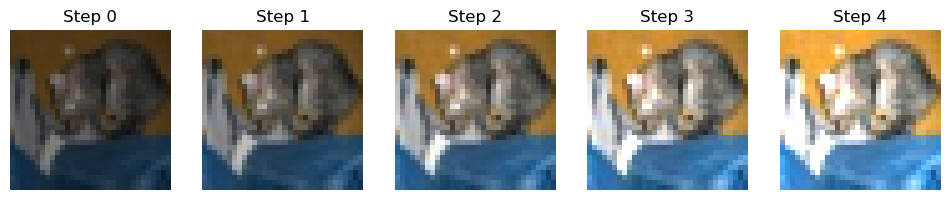

100%|████████████████████████████████████████| 169M/169M [00:11<00:00, 15.3MB/s]


Extracting ./data/cifar-100-python.tar.gz to ./data
=== CIFAR-100 Inputs (Out-of-Domain) ===
MSE: 0.568326, KL: 0.195696, CosSim: 0.834726


In [10]:
import torch
import torch.nn.functional as F
import numpy as np
import torchvision
import torchvision.transforms as T
import matplotlib.pyplot as plt



def get_logits(model, x):
    """
    Forward pass to get model logits.
    Assumes x is a batch of images: shape [B, C, H, W].
    """
    with torch.no_grad():
        return model(x)  # shape [B, num_classes]

def compare_model_outputs(modelA, modelB, inputs, device='cpu'):
    """
    Given a batch of inputs, compute:
      - MSE of logits
      - KL divergence of predicted distributions
      - Cosine similarity of logits
    Returns dict of average metrics over the batch.
    """
    inputs = inputs.to(device)
    logitsA = get_logits(modelA, inputs)
    logitsB = get_logits(modelB, inputs)

    # 1) MSE of logits
    mse = F.mse_loss(logitsA, logitsB).item()

    # 2) KL divergence between probability distributions
    #    For numeric stability, we do log_softmax first, then sum p * (log p - log q).
    #    We'll average across the batch.
    probsA = F.softmax(logitsA, dim=1)
    log_probsA = F.log_softmax(logitsA, dim=1)
    log_probsB = F.log_softmax(logitsB, dim=1)
    # KL(A||B) = sum( pA * (log pA - log pB) )
    kl_AB = torch.sum(probsA * (log_probsA - log_probsB), dim=1).mean().item()

    # 3) Cosine similarity of logits (we'll compute per sample, then average)
    #    Cos sim = dot(A,B) / (||A|| * ||B||)
    #    We'll get an average across the batch.
    cos_sims = []
    for i in range(logitsA.shape[0]):
        cos_sim = F.cosine_similarity(logitsA[i].unsqueeze(0),
                                      logitsB[i].unsqueeze(0), dim=1)
        cos_sims.append(cos_sim.item())
    cos_avg = np.mean(cos_sims)

    return {'mse': mse, 'kl_div': kl_AB, 'cosine': cos_avg}




def test_on_random_noise(modelA, modelB, num_samples=128, device='cpu'):
    """
    Generate random noise in [0,1], feed to both models, compare outputs.
    """
    # Create random noise input
    inputs = torch.rand(num_samples, 3, 32, 32)  # for a 3-channel 32x32 input
    metrics = compare_model_outputs(modelA, modelB, inputs, device=device)

    print("=== Random Noise Inputs ===")
    print(f"MSE: {metrics['mse']:.6f}, KL: {metrics['kl_div']:.6f}, CosSim: {metrics['cosine']:.6f}")
    return metrics



def test_on_augmented_cifar10(modelA, modelB, num_samples=128, device='cpu'):
    """
    Load CIFAR-10, apply random augmentations, compare outputs on a random subset.
    """
    # Basic random transforms (example)
    transform = T.Compose([
        T.RandomHorizontalFlip(),
        T.RandomCrop(32, padding=4),
        T.ToTensor()
    ])

    dataset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                           download=True, transform=transform)
    # Get random subset
    indices = np.random.choice(len(dataset), size=num_samples, replace=False)
    subset = torch.utils.data.Subset(dataset, indices)
    loader = torch.utils.data.DataLoader(subset, batch_size=num_samples)

    # Only one batch
    data_iter = iter(loader)
    images, _ = next(data_iter)  # we don't care about labels here

    metrics = compare_model_outputs(modelA, modelB, images, device=device)

    print("=== Augmented CIFAR-10 Inputs ===")
    print(f"MSE: {metrics['mse']:.6f}, KL: {metrics['kl_div']:.6f}, CosSim: {metrics['cosine']:.6f}")
    return metrics




def create_brightness_sweep(img, num_steps=5, delta=0.3):
    """
    Return a list of images by varying brightness from -delta to +delta in num_steps.
    """
    # We'll use torchvision transforms for brightness.
    images = []
    brightness_factors = np.linspace(-delta, delta, num_steps)
    for bf in brightness_factors:
        # The standard brightness factor is (1+bf). E.g. 1.0 is identity.
        # Negative would be less than 1, but let's clamp at 0. 
        bright_factor = 1.0 + bf
        tf = T.ColorJitter(brightness=[bright_factor, bright_factor])
        images.append(tf(img))
    return images

def test_systematic_grid(modelA, modelB, device='cpu'):
    """
    Example of taking a single CIFAR-10 image (or any image),
    then systematically varying brightness to see how outputs differ.
    """
    # 1) Get a single image from CIFAR-10 (test set), no transform
    dataset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                           download=True, transform=T.ToTensor())
    img, _ = dataset[0]  # Just pick the first image for demonstration
    
    # 2) Create a brightness sweep
    #    each entry is a 3x32x32 tensor
    sweep_imgs = create_brightness_sweep(img, num_steps=5, delta=0.5)

    # 3) Compare
    # We'll stack them into a batch
    batch = torch.stack(sweep_imgs, dim=0)
    metrics = compare_model_outputs(modelA, modelB, batch, device=device)

    print("=== Systematic Brightness Sweep ===")
    print(f"MSE: {metrics['mse']:.6f}, KL: {metrics['kl_div']:.6f}, CosSim: {metrics['cosine']:.6f}")

    # (Optional) visualize the images
    fig, axes = plt.subplots(1, len(sweep_imgs), figsize=(12,3))
    for i, ax in enumerate(axes):
        # Convert tensor to numpy image
        np_img = sweep_imgs[i].permute(1,2,0).numpy()
        ax.imshow(np_img)
        ax.axis('off')
        ax.set_title(f"Step {i}")
    plt.show()
    
    return metrics




def test_on_cifar100(modelA, modelB, num_samples=128, device='cpu'):
    """
    Compare outputs on CIFAR-100 (which is out-of-domain if trained on CIFAR-10).
    """
    transform = T.Compose([T.ToTensor()])
    dataset = torchvision.datasets.CIFAR100(root='./data', train=False,
                                            download=True, transform=transform)
    # pick random subset
    indices = np.random.choice(len(dataset), size=num_samples, replace=False)
    subset = torch.utils.data.Subset(dataset, indices)
    loader = torch.utils.data.DataLoader(subset, batch_size=num_samples)

    data_iter = iter(loader)
    images, _ = next(data_iter)  # ignore labels

    metrics = compare_model_outputs(modelA, modelB, images, device=device)

    print("=== CIFAR-100 Inputs (Out-of-Domain) ===")
    print(f"MSE: {metrics['mse']:.6f}, KL: {metrics['kl_div']:.6f}, CosSim: {metrics['cosine']:.6f}")
    return metrics




def main():
    if torch.backends.mps.is_available():
        device = "mps"
    else:
        device = "cpu"
    print("Using device:", device)
    

    model_standard.to(device)
    model_swapped.to(device)
    model_standard.eval()
    model_swapped.eval()

  
    
    # 1) Test on random noise
    _ = test_on_random_noise(model_standard, model_swapped, num_samples=128, device=device)

    # 2) Test on augmented CIFAR-10
    _ = test_on_augmented_cifar10(model_standard, model_swapped, num_samples=128, device=device)

    # 3) Systematic brightness sweep
    _ = test_systematic_grid(model_standard, model_swapped, device=device)

    # 4) Out-of-domain: CIFAR-100
    _ = test_on_cifar100(model_standard, model_swapped, num_samples=128, device=device)


if __name__ == "__main__":
    main()
